#Import and Load Data

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('deliveries.csv')
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


# Sorting the Data

The dataset is sorted by match_id, inning, over, and ball to ensure that deliveries are processed in the correct sequence.

This is important because partnership calculation depends on the correct order of balls.

In [15]:
df = df.sort_values(by=['match_id', 'inning', 'over', 'ball'])

In [16]:
print(df.columns)

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')


#Core Logic: Partnership Tracking

In [17]:
partnerships = []

for (match_id, inning), group in df.groupby(['match_id', 'inning']):

    current_pair = None
    current_runs = 0

    for _, row in group.iterrows():

        batsman = row['batter']
        non_striker = row['non_striker']

        pair = tuple(sorted([batsman, non_striker]))

        if current_pair != pair:
            if current_pair is not None:
                partnerships.append({
                    'match_id': match_id,
                    'inning': inning,
                    'pair': current_pair,
                    'runs': current_runs
                })
            current_pair = pair
            current_runs = 0

        current_runs += row['total_runs']

        if pd.notna(row['player_dismissed']):
            partnerships.append({
                'match_id': match_id,
                'inning': inning,
                'pair': current_pair,
                'runs': current_runs
            })
            current_pair = None
            current_runs = 0

    if current_pair is not None:
        partnerships.append({
            'match_id': match_id,
            'inning': inning,
            'pair': current_pair,
            'runs': current_runs
        })

partnership_df = pd.DataFrame(partnerships)

### Partnership Calculation Logic

A partnership is defined as the total runs scored by two batsmen while they are batting together.

The logic works as follows:

- The data is grouped by match and inning to process each innings separately.
- For each ball:
  - Identify the current batting pair (batter and non_striker).
  - If the pair changes, the previous partnership ends and a new one starts.
  - Runs scored are continuously added to the current partnership.
- If a wicket falls:
  - The partnership is recorded.
  - A new partnership begins with the next batsman.
- At the end of the innings, the last partnership is also recorded.

In [18]:
partnership_df.head()

,match_id,inning,pair,runs
0,335982,1,"(BB McCullum, SC Ganguly)",61
1,335982,1,"(BB McCullum, RT Ponting)",51
2,335982,1,"(BB McCullum, DJ Hussey)",60
3,335982,1,"(BB McCullum, Mohammad Hafeez)",50
4,335982,2,"(R Dravid, W Jaffer)",4


#Visualisation

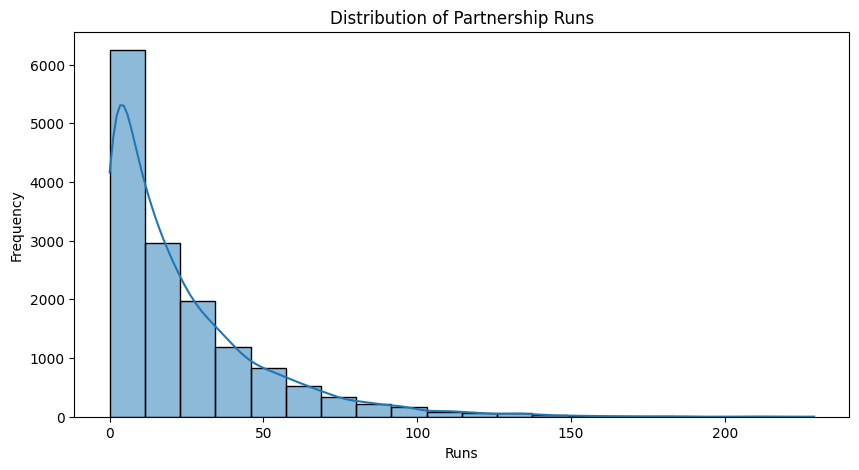

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(partnership_df['runs'], bins=20, kde=True)

plt.title("Distribution of Partnership Runs")
plt.xlabel("Runs")
plt.ylabel("Frequency")

plt.show()

A histogram is used to show the distribution of partnership runs.

- The x-axis represents partnership runs  
- The y-axis represents how many partnerships fall in that range  

This helps understand how common short and long partnerships are.

In [20]:
# Total partnerships
total_partnerships = len(partnership_df)

# 100+ partnerships
hundred_plus = partnership_df[partnership_df['runs'] >= 100]
num_100_plus = len(hundred_plus)

percentage_100_plus = (num_100_plus / total_partnerships) * 100

print(f"Total partnerships: {total_partnerships}")
print(f"100+ partnerships: {num_100_plus}")
print(f"Percentage of 100+ partnerships: {percentage_100_plus:.2f}%")

Total partnerships: 14707
100+ partnerships: 299
Percentage of 100+ partnerships: 2.03%


In [21]:
# Create bins
bins = [0, 20, 40, 60, 80, 100, 150, 200]
labels = ['0-20', '21-40', '41-60', '61-80', '81-100', '101-150', '151-200']

partnership_df['range'] = pd.cut(partnership_df['runs'], bins=bins, labels=labels)

# Count distribution
distribution = partnership_df['range'].value_counts().sort_index()

# Percentage distribution
percentage_distribution = (distribution / total_partnerships) * 100

print("Distribution:\n", distribution)
print("\nPercentage Distribution:\n", percentage_distribution)

# Most common range
most_common_range = distribution.idxmax()
print(f"\nMost common partnership range: {most_common_range}")

Distribution:
 range
0-20       7693
21-40      3128
41-60      1461
61-80       711
81-100      354
101-150     255
151-200      29
Name: count, dtype: int64

Percentage Distribution:
 range
0-20       52.308425
21-40      21.268784
41-60       9.934045
61-80       4.834433
81-100      2.407017
101-150     1.733868
151-200     0.197185
Name: count, dtype: float64

Most common partnership range: 0-20


### Explanation

- Calculated total partnerships.
- Found how many partnerships scored 100+ runs and their percentage.
- Grouped partnerships into ranges (0–20, 21–40, etc.).
- Calculated how many partnerships fall in each range and their percentages.

Helps to understand:
- Which partnerships are most common
- How rare big (100+ runs) partnerships are

#Highest partnership per match

In [22]:
max_per_match = partnership_df.groupby('match_id')['runs'].max().reset_index()

max_per_match.head()

,match_id,runs
0,335982,61
1,335983,73
2,335984,112
3,335985,55
4,335986,47


#Highest partnership in entire dataset

In [23]:
highest_partnership = partnership_df.loc[partnership_df['runs'].idxmax()]

highest_partnership

,7434
match_id,980987
inning,1
pair,"(AB de Villiers, V Kohli)"
runs,229
range,NaN


In [24]:
print("Highest Partnership in Dataset:")
print("Runs:", highest_partnership['runs'])
print("Players:", highest_partnership['pair'])
print("Match ID:", highest_partnership['match_id'])

Highest Partnership in Dataset:
Runs: 229
Players: ('AB de Villiers', 'V Kohli')
Match ID: 980987


### Final Insights

- **52.31%** of partnerships fall in the **0–20 runs** range, making it the most common partnership size.
- **21.27%** of partnerships are in the **21–40 runs** range, meaning over **73%** of partnerships stay below 40 runs.
- Only **2.03%** of partnerships exceed **100 runs**, indicating that century partnerships are extremely rare.
- Partnerships above **60 runs** account for less than **5%** of total partnerships, showing a sharp drop as runs increase.

- The highest partnership recorded in the dataset is **229 runs**, between **AB de Villiers and V Kohli** (match_id: 980987, innings: 1).

These results show that most partnerships are short-lived, largely due to frequent wickets, which continuously reset partnerships.